In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit
from sage.all import EllipticCurve, ZZ, primes_first_n, factor

OUTPUT_DIR = 'MW_torsion_curves/Trivial_torsion_family'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#=======================
# Trivial torsion family: y^2 = x^3 + d^2 x + d^3, d square-free integer.
# Quadratic twists of y^2 = x^3 + x + 1 (which has trivial torsion).
# Computing isogeny classes directly without Cremona database.
# Only processing curves with verified trivial torsion.
#=======================

NUM_PRIMES = 1000
PRIMES = list(primes_first_n(NUM_PRIMES))

def is_squarefree(n):
    """Check if n is square-free."""
    if n == 0:
        return False
    for p, e in factor(abs(n)):
        if e >= 2:
            return False
    return True

def get_squarefree_ds(d_max):
    """Get all square-free integers from 1 to d_max."""
    return [d for d in range(1, d_max + 1) if is_squarefree(d)]

def elliptic_curve_from_d(d):
    """Create elliptic curve y^2 = x^3 + d^2 x + d^3."""
    return EllipticCurve([ZZ(0), ZZ(0), ZZ(0), ZZ(d)**2, ZZ(d)**3])

def process_d(d):
    """Process a single square-free d value. Returns dict or None."""
    try:
        E = elliptic_curve_from_d(d)
        
        # Check for trivial torsion
        if E.torsion_order() != 1:
            return None  # Skip non-trivial torsion curves
        
        E_min = E.minimal_model()
        N = int(E_min.conductor())
        
        # Compute isogeny class directly (no Cremona database needed)
        iso_class = E_min.isogeny_class()
        rep = iso_class.curves[0].minimal_model()
        iso_key = tuple(int(a) for a in rep.a_invariants())
        iso_size = len(iso_class.curves)
        
        # Rank computation
        rk = int(E_min.rank())
        
        # Frobenius traces
        ap_list = [int(E_min.ap(p)) for p in PRIMES]
        
        return {'d': d, 'conductor': N, 'iso_key': iso_key, 
                'iso_size': iso_size, 'rank': rk, 'ap_list': ap_list}
    except Exception as e:
        print(f"Error d={d}: {e}")
        return None

def power_law(x, A, alpha):
    return A / (x**alpha)

# ============================================================================
# SCAN AND PROCESS
# ============================================================================

d_max = 1000  # Adjust as needed
all_ds = get_squarefree_ds(d_max)
print(f"Processing {len(all_ds)} square-free d values up to {d_max}...")
print("Filtering for trivial torsion curves...")

with Pool(processes=cpu_count()) as pool:
    results = list(tqdm(pool.imap(process_d, all_ds), total=len(all_ds)))

# Filter successful results
results = [r for r in results if r is not None]
print(f"Successfully processed {len(results)} curves with trivial torsion")
print(f"Rejected {len(all_ds) - len(results)} curves with non-trivial torsion")

# ============================================================================
# BUILD DATABASE
# ============================================================================

# Track all mappings
d_to_iso = {}           # d -> iso_key
iso_to_ds = {}          # iso_key -> list of d values
iso_to_data = {}        # iso_key -> {conductor, ap_list, iso_size, d_rep}

for r in results:
    d, iso_key = r['d'], r['iso_key']
    d_to_iso[d] = iso_key
    
    if iso_key not in iso_to_ds:
        iso_to_ds[iso_key] = []
        iso_to_data[iso_key] = {
            'conductor': r['conductor'],
            'ap_list': r['ap_list'],
            'iso_size': r['iso_size'],
            'rank': r['rank'],
            'd_rep': d  # First d encountered as representative
        }
    iso_to_ds[iso_key].append(d)

# Extract unique isogeny class data
isogeny_classes = list(iso_to_data.keys())
d_reps = [iso_to_data[iso]['d_rep'] for iso in isogeny_classes]
conductors = [iso_to_data[iso]['conductor'] for iso in isogeny_classes]
ap_lists = [iso_to_data[iso]['ap_list'] for iso in isogeny_classes]
iso_sizes = [iso_to_data[iso]['iso_size'] for iso in isogeny_classes]
ranks = [iso_to_data[iso]['rank'] for iso in isogeny_classes]

# Multiplicities: how many d values map to each isogeny class
multiplicities_by_iso = {iso: len(ds) for iso, ds in iso_to_ds.items()}
multiplicities = [multiplicities_by_iso[d_to_iso[d]] for d in all_ds if d in d_to_iso]

print(f"Found {len(isogeny_classes)} distinct isogeny classes")
print(f"Conductor range: [{min(conductors)}, {max(conductors)}]")

# ============================================================================
# COMPUTE AVERAGE FROBENIUS TRACES (OVERALL AND BY RANK)
# ============================================================================

ap_array = np.array(ap_lists)
avg_frob_traces = np.mean(ap_array, axis=0)
std_frob_traces = np.std(ap_array, axis=0)

# Separate by rank
rank_to_indices = {}
for i, rk in enumerate(ranks):
    if rk not in rank_to_indices:
        rank_to_indices[rk] = []
    rank_to_indices[rk].append(i)

avg_frob_by_rank = {}
std_frob_by_rank = {}
count_by_rank = {}

for rk, indices in rank_to_indices.items():
    rk_traces = np.array([ap_lists[i] for i in indices])
    avg_frob_by_rank[rk] = np.mean(rk_traces, axis=0)
    std_frob_by_rank[rk] = np.std(rk_traces, axis=0)
    count_by_rank[rk] = len(indices)
    print(f"Rank {rk}: {count_by_rank[rk]} isogeny classes")

print(f"Average Frobenius trace statistics computed over {len(ap_lists)} isogeny classes")

# ============================================================================
# SAVE DATA
# ============================================================================

print("Saving data...")
scan_data = {
    'family': 'y^2 = x^3 + d^2 x + d^3 (trivial torsion twists)',
    'base_curve': 'y^2 = x^3 + x + 1',
    'all_ds': all_ds,
    'd_reps': d_reps,
    'isogeny_classes': isogeny_classes,
    'conductors': conductors,
    'ranks': ranks,
    'ap_lists': ap_lists,
    'iso_sizes': iso_sizes,
    'd_to_iso': d_to_iso,
    'iso_to_ds': iso_to_ds,
    'iso_to_data': iso_to_data,
    'multiplicities_by_iso': multiplicities_by_iso,
    'avg_frob_traces': avg_frob_traces.tolist(),
    'std_frob_traces': std_frob_traces.tolist(),
    'avg_frob_by_rank': {rk: arr.tolist() for rk, arr in avg_frob_by_rank.items()},
    'std_frob_by_rank': {rk: arr.tolist() for rk, arr in std_frob_by_rank.items()},
    'count_by_rank': count_by_rank,
    'primes': PRIMES,
    'd_max': d_max,
    'num_isogeny_classes': len(isogeny_classes),
    'num_ds_processed': len(results),
    'num_ds_rejected': len(all_ds) - len(results)
}
save(scan_data, f'{OUTPUT_DIR}/d_max_{d_max}_scan_data.sobj')

# ============================================================================
# PLOTTING
# ============================================================================

print("Creating plots...")
sqrt_primes = np.sqrt(PRIMES)

# 1. Multiplicity vs d
processed_ds = [d for d in all_ds if d in d_to_iso]
processed_mults = [multiplicities_by_iso[d_to_iso[d]] for d in processed_ds]

plt.figure(figsize=(14, 7))
scatter = plt.scatter(processed_ds, processed_mults, c=processed_mults, cmap='plasma',
                      alpha=0.6, s=15, edgecolors='none')
plt.colorbar(scatter, label='Multiplicity')
plt.xlabel(r'$d$', fontsize=14)
plt.ylabel('Multiplicity (# d → same isogeny class)', fontsize=14)
plt.title(fr'Isogeny class multiplicity: $y^2 = x^3 + d^2 x + d^3$ (sq-free $d \leq {d_max}$, trivial torsion)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Multiplicity = 1')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_multiplicity_vs_d.png', dpi=150)
plt.close()

# 2. d_rep distribution
plt.figure(figsize=(12, 6))
plt.hist(d_reps, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(r'$d$ representative', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title(fr'Distribution of $d$ representatives ({len(d_reps)} unique isogeny classes)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_d_rep_distribution.png', dpi=150)
plt.close()

# 3. Conductor vs d_rep
plt.figure(figsize=(12, 7))
plt.scatter(d_reps, conductors, c=np.log10(conductors), cmap='viridis', 
            alpha=0.6, s=20, edgecolors='none')
plt.colorbar(label=r'$\log_{10}(N)$')
plt.xlabel(r'$d$ representative', fontsize=14)
plt.ylabel(r'Conductor $N$', fontsize=14)
plt.title(fr'Conductor vs $d$: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_conductor_vs_d.png', dpi=150)
plt.close()

# 4. Conductor distribution with power law fit
plt.figure(figsize=(14, 6))
counts_N, bins_N, _ = plt.hist(conductors, bins=100, density=True, alpha=0.6, label='Data')
bin_centers = (bins_N[:-1] + bins_N[1:]) / 2
mask = counts_N > 0

try:
    popt, _ = curve_fit(power_law, bin_centers[mask], counts_N[mask], p0=[1e6, 1.5], maxfev=10000)
    A_fit, alpha_fit = popt
    x_fit = np.linspace(min(conductors), max(conductors), 1000)
    plt.plot(x_fit, power_law(x_fit, A_fit, alpha_fit), 'r-', linewidth=2,
             label=fr'Power law: $\alpha={alpha_fit:.3f}$')
except Exception as e:
    print(f"Power law fit failed: {e}")

plt.xlabel(r"Conductor $N$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(fr"Conductor distribution: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_conductor_distribution.png', dpi=150)
plt.close()

# 5. Isogeny class multiplicity histogram
mult_counts = {}
for m in multiplicities_by_iso.values():
    mult_counts[m] = mult_counts.get(m, 0) + 1

plt.figure(figsize=(12, 6))
mult_vals = sorted(mult_counts.keys())
mult_freqs = [mult_counts[m] for m in mult_vals]
plt.bar(mult_vals, mult_freqs, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Multiplicity', fontsize=14)
plt.ylabel('Number of isogeny classes', fontsize=14)
plt.title(fr'Isogeny class multiplicities: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_multiplicity_histogram.png', dpi=150)
plt.close()

# 6. Average Frobenius traces by rank
plt.figure(figsize=(14, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(avg_frob_by_rank)))
for i, rk in enumerate(sorted(avg_frob_by_rank.keys())):
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[rk], alpha=0.6, s=10, 
                color=colors[i], label=f'Rank {rk} (n={count_by_rank[rk]})')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
plt.title(fr"Average Frobenius traces by rank: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_avg_frobenius_traces_by_rank.png', dpi=150)
plt.close()

# 7. Overall average Frobenius traces
plt.figure(figsize=(14, 7))
plt.scatter(range(NUM_PRIMES), avg_frob_traces, alpha=0.6, s=10, 
            label=f'Average (n={len(ap_lists)} classes)')
plt.fill_between(range(NUM_PRIMES), 
                 avg_frob_traces - std_frob_traces, 
                 avg_frob_traces + std_frob_traces, 
                 alpha=0.2, label='±1 std dev')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
plt.title(fr"Overall average Frobenius traces: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_avg_frobenius_traces.png', dpi=150)
plt.close()

# 8. Rank 0 vs Rank 1 Frobenius traces
if 0 in avg_frob_by_rank and 1 in avg_frob_by_rank:
    plt.figure(figsize=(14, 7))
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[0], alpha=0.6, s=12,
                color='blue', label=f'Rank 0 (n={count_by_rank[0]})')
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[1], alpha=0.6, s=12,
                color='red', label=f'Rank 1 (n={count_by_rank[1]})')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)
    plt.xlabel(r"Prime index $i$", fontsize=12)
    plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
    plt.title(fr"Rank 0 vs Rank 1: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_frobenius_rank0_vs_rank1.png', dpi=150)
    plt.close()
    
    # Normalized version
    plt.figure(figsize=(14, 7))
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[0] / sqrt_primes, alpha=0.6, s=12,
                color='blue', label=f'Rank 0 (n={count_by_rank[0]})')
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[1] / sqrt_primes, alpha=0.6, s=12,
                color='red', label=f'Rank 1 (n={count_by_rank[1]})')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)
    plt.xlabel(r"Prime index $i$", fontsize=12)
    plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
    plt.title(fr"Rank 0 vs Rank 1 normalized: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_normalized_rank0_vs_rank1.png', dpi=150)
    plt.close()
else:
    print("Warning: Need both rank 0 and rank 1 curves for comparison plot")

# 9. Frobenius traces normalized by sqrt(p)
normalized_traces = avg_frob_traces / sqrt_primes

plt.figure(figsize=(14, 7))
plt.scatter(range(NUM_PRIMES), normalized_traces, alpha=0.6, s=10)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
plt.title(fr"Normalized average Frobenius traces: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_normalized_frobenius_traces.png', dpi=150)
plt.close()

# 10. Normalized Frobenius traces by rank
plt.figure(figsize=(14, 7))
for i, rk in enumerate(sorted(avg_frob_by_rank.keys())):
    normalized = avg_frob_by_rank[rk] / sqrt_primes
    plt.scatter(range(NUM_PRIMES), normalized, alpha=0.6, s=10,
                color=colors[i], label=f'Rank {rk} (n={count_by_rank[rk]})')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
plt.title(fr"Normalized Frobenius by rank: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_normalized_frobenius_by_rank.png', dpi=150)
plt.close()

# 11. Isogeny class size distribution
plt.figure(figsize=(12, 6))
size_counts = {}
for s in iso_sizes:
    size_counts[s] = size_counts.get(s, 0) + 1
sizes = sorted(size_counts.keys())
size_freqs = [size_counts[s] for s in sizes]
plt.bar(sizes, size_freqs, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Isogeny class size', fontsize=14)
plt.ylabel('Number of isogeny classes', fontsize=14)
plt.title(fr'Isogeny class sizes: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_isogeny_class_sizes.png', dpi=150)
plt.close()

# 12. Murmuration plot: avg a_p vs prime index (key diagnostic)
plt.figure(figsize=(14, 7))
for i, rk in enumerate(sorted(avg_frob_by_rank.keys())):
    plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[rk], alpha=0.6, s=10,
                color=colors[i], label=f'Rank {rk} (n={count_by_rank[rk]})')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"$\langle a_{p_i} \rangle$", fontsize=12)
plt.title(fr"Murmuration plot: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/d_max_{d_max}_murmuration_plot.png', dpi=150)
plt.close()

print(f"\nSummary:")
print(f"  Family: y^2 = x^3 + d^2 x + d^3 (trivial torsion)")
print(f"  d_max: {d_max}")
print(f"  Square-free d values tested: {len(all_ds)}")
print(f"  Curves with trivial torsion: {len(results)}")
print(f"  Curves rejected (non-trivial torsion): {len(all_ds) - len(results)}")
print(f"  Unique isogeny classes: {len(isogeny_classes)}")
print(f"  Conductor range: [{min(conductors)}, {max(conductors)}]")
print(f"  Rank distribution: {count_by_rank}")
print(f"Done!")

In [11]:
scan_data = load('MW_torsion_curves/Trivial_torsion_family/d_max_1000_scan_data.sobj')

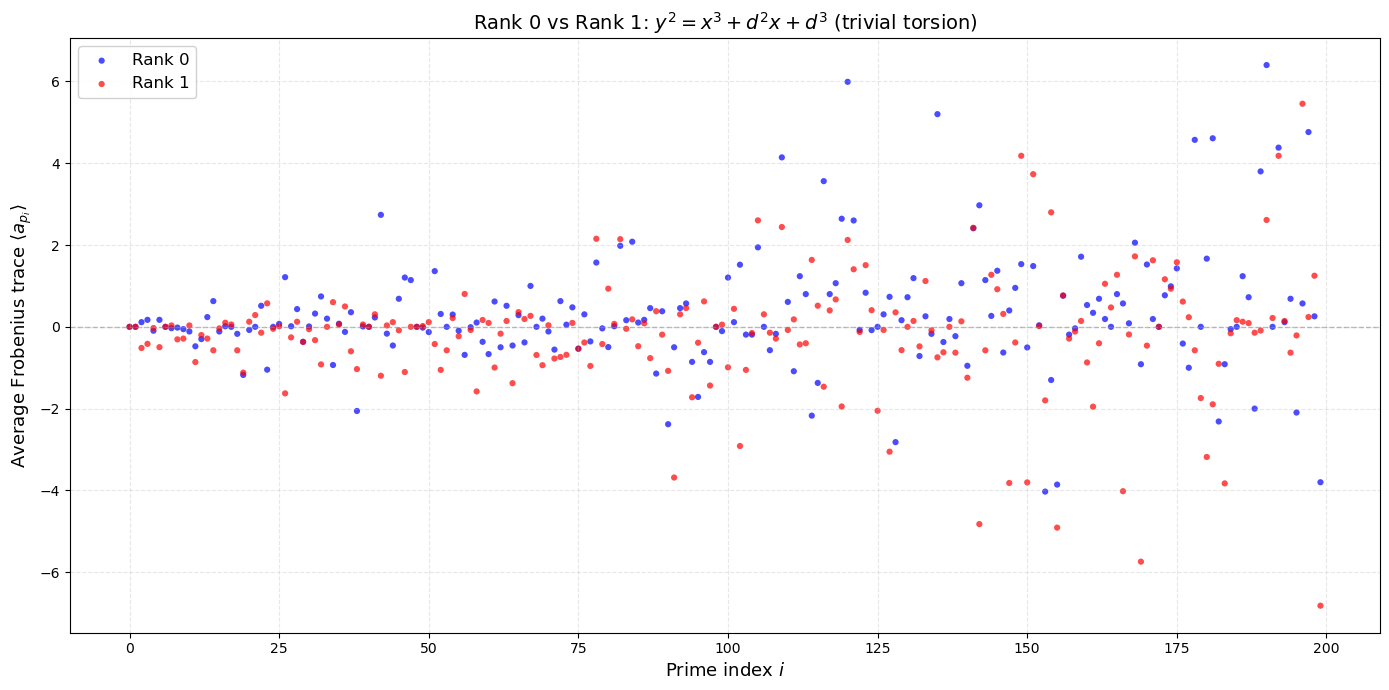

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.scatter(range(200), scan_data['avg_frob_by_rank'][0][:200], 
           alpha=0.7, s=20, color='blue', label='Rank 0', edgecolors='none')
plt.scatter(range(200), scan_data['avg_frob_by_rank'][1][:200], 
           alpha=0.7, s=20, color='red', label='Rank 1', edgecolors='none')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.xlabel(r'Prime index $i$', fontsize=13)
plt.ylabel(r'Average Frobenius trace $\langle a_{p_i} \rangle$', fontsize=13)
plt.title(r'Rank 0 vs Rank 1: $y^2 = x^3 + d^2 x + d^3$ (trivial torsion)', fontsize=14)
plt.legend(fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()